In [2]:
import random

In [4]:
import numpy as np
import random

data = np.array([
    [2.5, 4.5],
    [3.0, 3.5],
    [7.1, 6.7],
    [6.0, 7.3],
    [2.0, 1.0],
    [7.8, 8.5],
    [6.8, 2.2],
    [8.2, 3.1],
    [7.5, 4.0],
    [1.5, 3.0]
])

k = 3

# Initialize centroids randomly from data points
centroids = data[random.sample(range(len(data)), k)]

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

for iteration in range(100):
    clusters = [[] for _ in range(k)]

    # Assign points to closest centroid
    for point in data:
        distances = [euclidean_distance(point, centroid) for centroid in centroids]
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)

    old_centroids = centroids.copy()

    # Recalculate centroids as mean of clusters
    for i in range(k):
        if clusters[i]:  # Avoid division by zero
            centroids[i] = np.mean(clusters[i], axis=0)

    # Check for convergence (if centroids do not change)
    if np.allclose(centroids, old_centroids):
        print(f"Converged after {iteration + 1} iterations")
        break

print("------- K-Means Clustering -------")
print("Final centroids:")
print(centroids)

for i, cluster in enumerate(clusters):
    print(f"Cluster {i}: {np.array(cluster)}")


Converged after 2 iterations
------- K-Means Clustering -------
Final centroids:
[[7.5        3.1       ]
 [6.96666667 7.5       ]
 [2.25       3.        ]]
Cluster 0: [[6.8 2.2]
 [8.2 3.1]
 [7.5 4. ]]
Cluster 1: [[7.1 6.7]
 [6.  7.3]
 [7.8 8.5]]
Cluster 2: [[2.5 4.5]
 [3.  3.5]
 [2.  1. ]
 [1.5 3. ]]


In [5]:
import numpy as np
from math import inf

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def hierarchical_clustering(data, k):
    # Start with each point as its own cluster
    clusters = [[point] for point in data]

    while len(clusters) > k:
        min_dist = inf
        to_merge = (None, None)

        # Find two closest clusters (using centroid linkage)
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                centroid_i = np.mean(clusters[i], axis=0)
                centroid_j = np.mean(clusters[j], axis=0)
                dist = euclidean_distance(centroid_i, centroid_j)

                if dist < min_dist:
                    min_dist = dist
                    to_merge = (i, j)

        i, j = to_merge
        # Merge clusters
        merged_cluster = clusters[i] + clusters[j]

        # Remove old clusters and add merged cluster
        clusters = [clusters[idx] for idx in range(len(clusters)) if idx not in (i, j)]
        clusters.append(merged_cluster)

    return clusters

# Run hierarchical clustering with k=3 clusters
hier_clusters = hierarchical_clustering(data, k=3)

print("------- Hierarchical Clustering -------")
for i, cluster in enumerate(hier_clusters):
    print(f"Cluster {i}: {np.array(cluster)}")


------- Hierarchical Clustering -------
Cluster 0: [[6.8 2.2]
 [8.2 3.1]
 [7.5 4. ]]
Cluster 1: [[7.8 8.5]
 [7.1 6.7]
 [6.  7.3]]
Cluster 2: [[2.  1. ]
 [1.5 3. ]
 [2.5 4.5]
 [3.  3.5]]


In [6]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans

# Generate synthetic large dataset: 1 million samples, 10 features
X_large = np.random.rand(1_000_000, 10)

# Initialize MiniBatchKMeans with desired clusters and batch size
k = 10
mbk = MiniBatchKMeans(n_clusters=k, batch_size=10_000, random_state=42)

# Fit model on large dataset
mbk.fit(X_large)

# Output cluster centers and sample labels
print("Cluster centers:\n", mbk.cluster_centers_)
print("Sample cluster labels:", mbk.labels_[:20])


Cluster centers:
 [[0.64708207 0.30142047 0.77266322 0.31199252 0.48855642 0.57418431
  0.51817365 0.34216987 0.6420047  0.48508537]
 [0.35212236 0.58658707 0.47590554 0.70365555 0.55469742 0.39087027
  0.58036285 0.27702771 0.74371835 0.65152992]
 [0.43532362 0.60399524 0.42517105 0.28703798 0.7245609  0.4626247
  0.37931598 0.68397359 0.71192239 0.36580196]
 [0.35681864 0.5066016  0.62982579 0.6456015  0.58921037 0.29840554
  0.55748578 0.49339817 0.27463861 0.24132325]
 [0.66338135 0.38503023 0.29937764 0.67945282 0.46318756 0.6388434
  0.33023573 0.27366589 0.44312894 0.3626917 ]
 [0.66268379 0.39084983 0.48440972 0.65918703 0.73698673 0.49219225
  0.59260838 0.74389384 0.46319242 0.68808487]
 [0.48231553 0.47489999 0.4532102  0.60276994 0.20403768 0.52585013
  0.41066725 0.77998398 0.62375638 0.4455316 ]
 [0.44010935 0.73281153 0.70610739 0.49154474 0.48775729 0.6822836
  0.32365152 0.49037559 0.30863357 0.65819889]
 [0.53838864 0.71631517 0.31859061 0.28311978 0.44503917 0.618873

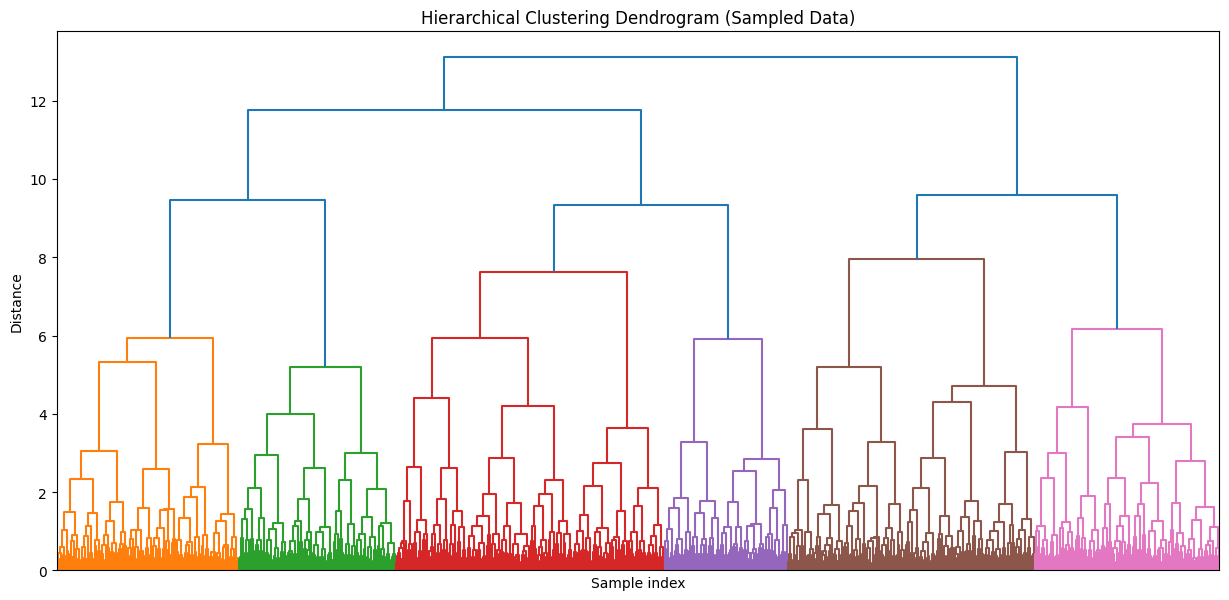

Sample cluster labels: [9 0 8 1 2 3 8 6 3 1 6 7 2 1 2 0 3 7 4 8]


In [7]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate synthetic large dataset
X = np.random.rand(100_000, 10)

# Downsample for dendrogram (max 2000 samples)
max_samples = 2000
idx = np.random.choice(len(X), max_samples, replace=False)
X_sample = X[idx]

# Reduce dimensions with PCA to speed up
pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_sample)

# Compute linkage matrix and plot dendrogram
linked = linkage(X_reduced, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram (Sampled Data)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

# Fit AgglomerativeClustering on sample
agg = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels_sample = agg.fit_predict(X_reduced)
print("Sample cluster labels:", labels_sample[:20])
